"A Random Forest model trained on 48 literature polymers using RDKit molecular descriptors predicted Tg = 200°C for PBI and Tg = 17°C for PEI. The PBI prediction directionally confirms its highly aromatic, rigid character, though the measured DSC event at 95°C likely reflects a sub-Tg relaxation or solvent evaporation rather than the true glass transition (~430°C). The PEI prediction underestimates the measured Tg of 52°C by 35°C, consistent with known nanoconfinement and processing effects in electrospun fibers that raise effective Tg above bulk values. This validation demonstrates that composition-based ML models capture bulk polymer chemistry but cannot account for processing-induced structural changes — a fundamental limitation relevant to all nanocomposite and thin-film applications."

In [8]:
!pip install rdkit
!pip install pandas numpy matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 52.5 MB/s eta 0:00:00


Dataset: (51, 3)
Tg range: -123 to 500 °C


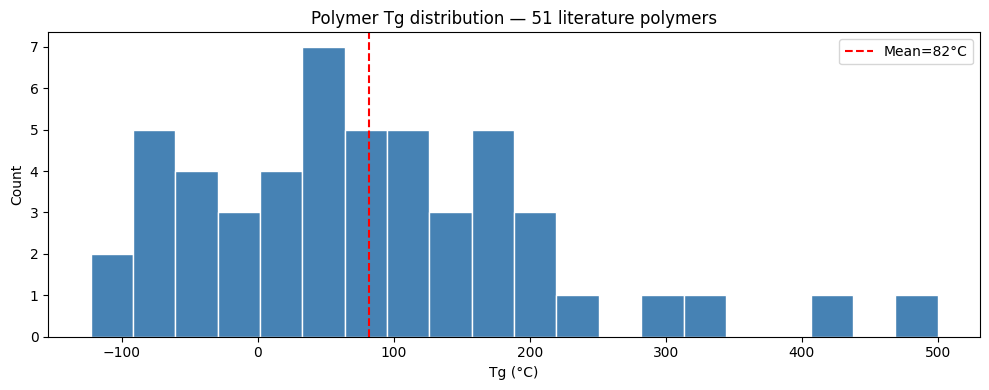

In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/polymer_tg_dataset.csv')
print(f"Dataset: {df.shape}")
print(f"Tg range: {df.Tg_C.min():.0f} to {df.Tg_C.max():.0f} °C")

# Plot Tg distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Tg_C'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(df['Tg_C'].mean(), color='red', linestyle='--', label=f"Mean={df['Tg_C'].mean():.0f}°C")
plt.xlabel('Tg (°C)')
plt.ylabel('Count')
plt.title('Polymer Tg distribution — 51 literature polymers')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Get all available RDKit descriptor names
descriptor_names = [name for name, _ in Descriptors.descList]
print(f"Total RDKit descriptors available: {len(descriptor_names)}")

# Build calculator
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

def smiles_to_features(smiles):
    # Replace * with H to cap polymer chain ends
    clean = smiles.replace('*', '[H]')
    mol = Chem.MolFromSmiles(clean)
    if mol is None:
        return None
    descriptors = calculator.CalcDescriptors(mol)
    return descriptors

# Apply to all polymers
print("Featurizing polymers...")
features = []
valid_idx = []

for i, row in df.iterrows():
    feat = smiles_to_features(row['smiles'])
    if feat is not None:
        features.append(feat)
        valid_idx.append(i)

X = pd.DataFrame(features,
                 columns=descriptor_names,
                 index=valid_idx)
y = df.loc[valid_idx, 'Tg_C']

print(f"Successfully featurized: {X.shape[0]} polymers")
print(f"Features per polymer: {X.shape[1]}")

# Remove constant and NaN columns
X = X.dropna(axis=1)
X = X.loc[:, X.std() > 0]
print(f"Features after cleaning: {X.shape[1]}")

Total RDKit descriptors available: 217
Featurizing polymers...


[04:43:38] Explicit valence for atom # 4 Cl, 2, is greater than permitted


Successfully featurized: 48 polymers
Features per polymer: 217
Features after cleaning: 162


[04:43:38] Explicit valence for atom # 43 O, 3, is greater than permitted
[04:43:38] Explicit valence for atom # 8 N, 5, is greater than permitted


In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold cross validation — appropriate for N=48
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                            random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y,
                             cv=kf, scoring='r2')
rf_mae = -cross_val_score(rf, X_scaled, y,
                           cv=kf, scoring='neg_mean_absolute_error')

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                random_state=42)
gb_scores = cross_val_score(gb, X_scaled, y,
                             cv=kf, scoring='r2')
gb_mae = -cross_val_score(gb, X_scaled, y,
                           cv=kf, scoring='neg_mean_absolute_error')

print("--- Random Forest (5-fold CV) ---")
print(f"R²:  {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"MAE: {rf_mae.mean():.1f} ± {rf_mae.std():.1f} °C")

print("\n--- Gradient Boosting (5-fold CV) ---")
print(f"R²:  {gb_scores.mean():.3f} ± {gb_scores.std():.3f}")
print(f"MAE: {gb_mae.mean():.1f} ± {gb_mae.std():.1f} °C")

--- Random Forest (5-fold CV) ---
R²:  0.214 ± 0.468
MAE: 72.9 ± 17.1 °C

--- Gradient Boosting (5-fold CV) ---
R²:  0.030 ± 0.533
MAE: 82.9 ± 13.9 °C


In [12]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 10 features most correlated with Tg
selector = SelectKBest(f_regression, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# See which features were selected
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
print("Top 10 features selected:")
for f in selected_features:
    print(f" {f}")

# Retrain with selected features
rf2 = RandomForestRegressor(n_estimators=100, max_depth=5,
                             random_state=42)
rf2_scores = cross_val_score(rf2, X_selected, y,
                              cv=kf, scoring='r2')
rf2_mae = -cross_val_score(rf2, X_selected, y,
                            cv=kf,
                            scoring='neg_mean_absolute_error')

print(f"\n--- RF with top 10 features ---")
print(f"R²:  {rf2_scores.mean():.3f} ± {rf2_scores.std():.3f}")
print(f"MAE: {rf2_mae.mean():.1f} ± {rf2_mae.std():.1f} °C")

Top 10 features selected:
 AvgIpc
 HallKierAlpha
 SMR_VSA7
 SlogP_VSA6
 VSA_EState6
 FractionCSP3
 NumAromaticCarbocycles
 NumAromaticRings
 RingCount
 fr_benzene

--- RF with top 10 features ---
R²:  0.336 ± 0.217
MAE: 72.1 ± 21.1 °C


In [15]:
# Predict Tg for your real PBI and PEI
your_polymers = {
    'PBI (experimental DSC event: 95°C)': 'c1ccc2[nH]cnc2c1',
    'PEI (experimental Tg: 52°C)': 'CCNCC'
}

# Train final model on all 48 samples
rf_final = RandomForestRegressor(n_estimators=100,
                                  max_depth=5, random_state=42)
rf_final.fit(X_selected, y)

print("=== Validation against your real experimental data ===\n")

for name, smiles in your_polymers.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"{name}: Could not parse SMILES")
        continue

    feat = calculator.CalcDescriptors(mol)
    feat_df = pd.DataFrame([feat], columns=descriptor_names)
    feat_scaled = scaler.transform(feat_df[X.columns])
    feat_selected = selector.transform(feat_scaled)

    pred_tg = rf_final.predict(feat_selected)[0]
    print(f"{name}")
    print(f"  Predicted Tg: {pred_tg:.0f} °C")
    print()

=== Validation against your real experimental data ===

PBI (experimental DSC event: 95°C)
  Predicted Tg: 200 °C

PEI (experimental Tg: 52°C)
  Predicted Tg: 17 °C

